# 03 - Feature Extraction: PCA vs Manual Features

**DSR Pipeline Phase: Data Transformation**

This notebook compares two feature representations for the clustering models:
- **Path A (Signal PCA):** Direct signal scaled + PCA retaining 95% variance
- **Path B (Manual Features):** 12 handcrafted morphological, temporal, and spectral features

The autoencoder uses the full 200-dimensional scaled signal (Path A without PCA).

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.data.loader import MITBIHLoader
from ecg_anomaly.preprocessing.pipeline import PreprocessingPipeline
from ecg_anomaly.features.signal_pca import SignalPCAExtractor
from ecg_anomaly.features.manual import ManualFeatureExtractor, FEATURE_NAMES

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()

## 1. Load and Preprocess Data

In [3]:
loader = MITBIHLoader(config)
dataset = loader.load(config.dataset_path)

pipeline = PreprocessingPipeline(config)
preprocessed = pipeline.run(dataset)

print(f"Input shape: {preprocessed.segments.shape}")
print(f"Labels: {preprocessed.labels.shape} (Normal={int(np.sum(preprocessed.labels==0)):,}, Anomalous={int(np.sum(preprocessed.labels==1)):,})")

00:43:00 [ecg_anomaly.data.loader] INFO: Cargados 44 registros: 100733 latidos (90125 normal, 10608 anomalo)
00:43:04 [ecg_anomaly.preprocessing.pipeline] INFO: Preprocesamiento completo: 100705 latidos [100705, 200] (normal=90099, anomalo=10606)


Input shape: (100705, 200)
Labels: (100705,) (Normal=90,099, Anomalous=10,606)


## 2. Path A: Signal PCA

StandardScaler + PCA with 95% variance retention.
This reduces from 200 dimensions to a much smaller number of principal components.

In [4]:
pca_extractor = SignalPCAExtractor(variance_threshold=config.pca_variance_threshold)
X_pca = pca_extractor.fit_transform(preprocessed.segments)

print(f"Original dimensions: {preprocessed.segments.shape[1]}")
print(f"PCA components: {pca_extractor.n_components}")
print(f"Variance retained: {pca_extractor.explained_variance_ratio * 100:.1f}%")
print(f"Output shape: {X_pca.shape}")

00:45:30 [ecg_anomaly.features.signal_pca] INFO: PCA: 200 -> 12 componentes (95.3% varianza retenida)


Original dimensions: 200
PCA components: 12
Variance retained: 95.3%
Output shape: (100705, 12)


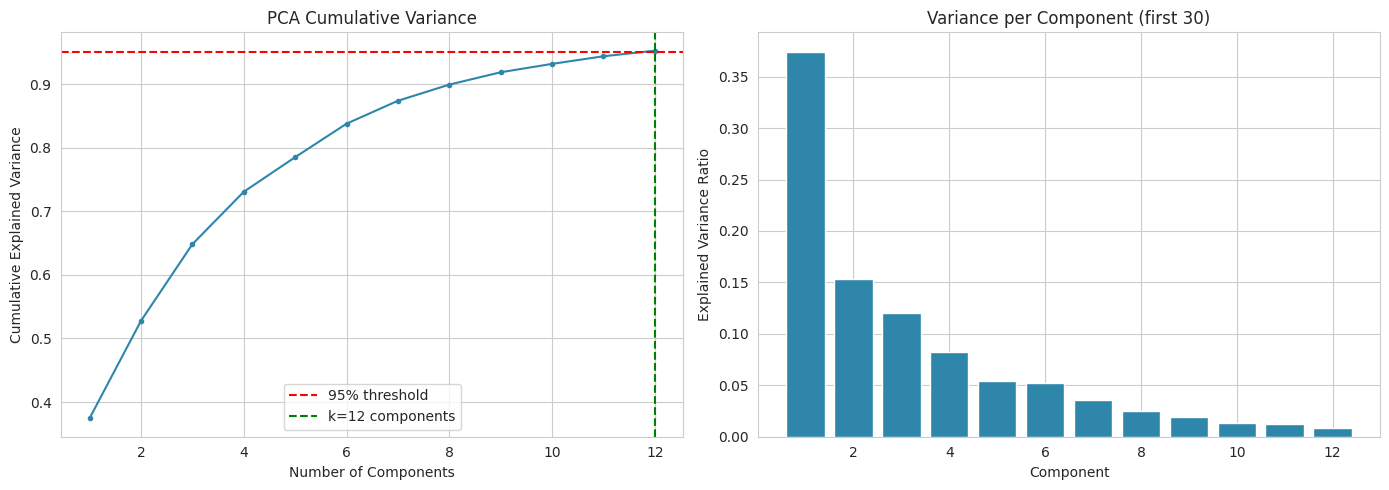

In [5]:
# Cumulative variance curve
cumvar = np.cumsum(pca_extractor.pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance
axes[0].plot(range(1, len(cumvar) + 1), cumvar, "o-", markersize=3, color="#2E86AB")
axes[0].axhline(config.pca_variance_threshold, color="red", linestyle="--",
                label=f"{config.pca_variance_threshold*100:.0f}% threshold")
axes[0].axvline(pca_extractor.n_components, color="green", linestyle="--",
                label=f"k={pca_extractor.n_components} components")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA Cumulative Variance")
axes[0].legend()

# Individual variance per component (first 30)
n_show = min(30, len(pca_extractor.pca.explained_variance_ratio_))
axes[1].bar(range(1, n_show + 1), pca_extractor.pca.explained_variance_ratio_[:n_show], color="#2E86AB")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Explained Variance Ratio")
axes[1].set_title("Variance per Component (first 30)")

plt.tight_layout()
plt.show()

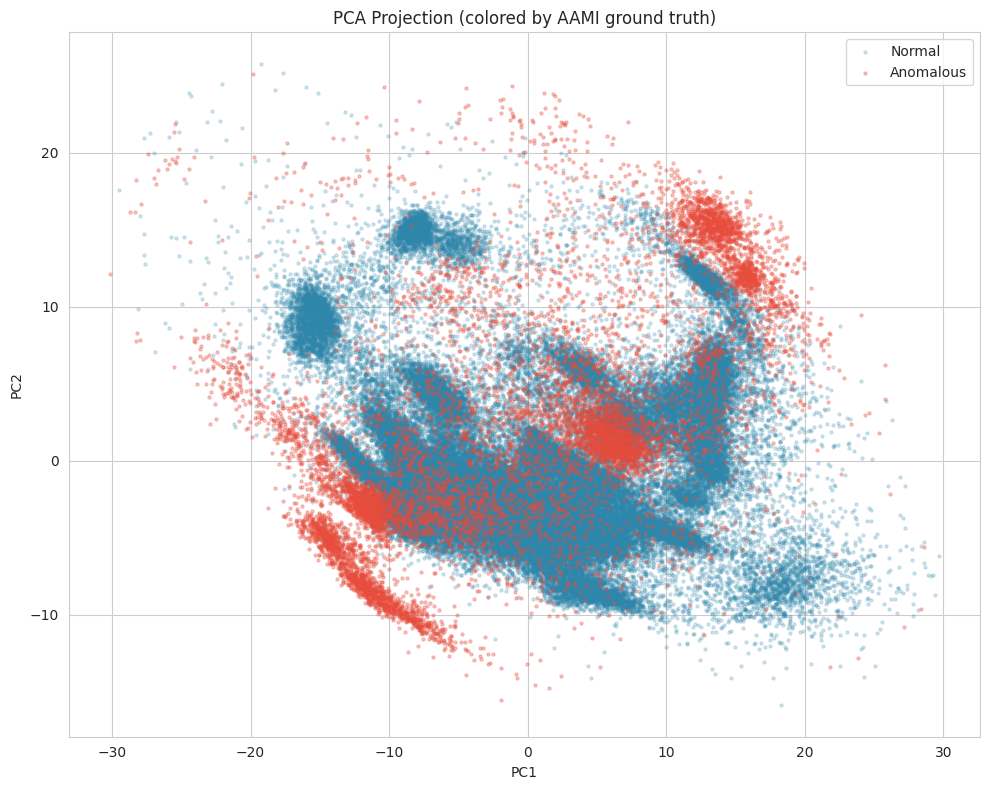

In [6]:
# PCA scatter: first two components colored by true label
fig, ax = plt.subplots(figsize=(10, 8))
normal_mask = preprocessed.labels == 0
anomaly_mask = preprocessed.labels == 1

ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], alpha=0.2, s=5, c="#2E86AB", label="Normal")
ax.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], alpha=0.3, s=5, c="#E74C3C", label="Anomalous")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Projection (colored by AAMI ground truth)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Path B: Manual Feature Extraction

Extracts 12 features per beat across 4 categories:
- **Morphological (4):** R amplitude, S amplitude, QRS duration, amplitude range
- **Temporal (3):** RR interval, RR ratio, RR difference
- **Statistical (3):** Mean, std, kurtosis
- **Spectral (2):** Dominant frequency, spectral energy

In [7]:
manual_extractor = ManualFeatureExtractor()
X_manual = manual_extractor.extract(
    preprocessed.segments,
    preprocessed.r_peaks_flat,
    fs=config.sampling_rate,
)

print(f"Manual features shape: {X_manual.shape}")
print(f"Feature names: {FEATURE_NAMES}")

00:48:46 [ecg_anomaly.features.manual] INFO: Features manuales: 100705 latidos x 12 features


Manual features shape: (100705, 12)
Feature names: ['r_amplitude', 's_amplitude', 'qrs_duration', 'amplitude_range', 'rr_current', 'rr_ratio', 'rr_diff', 'mean', 'std', 'kurtosis', 'dominant_freq', 'spectral_energy']


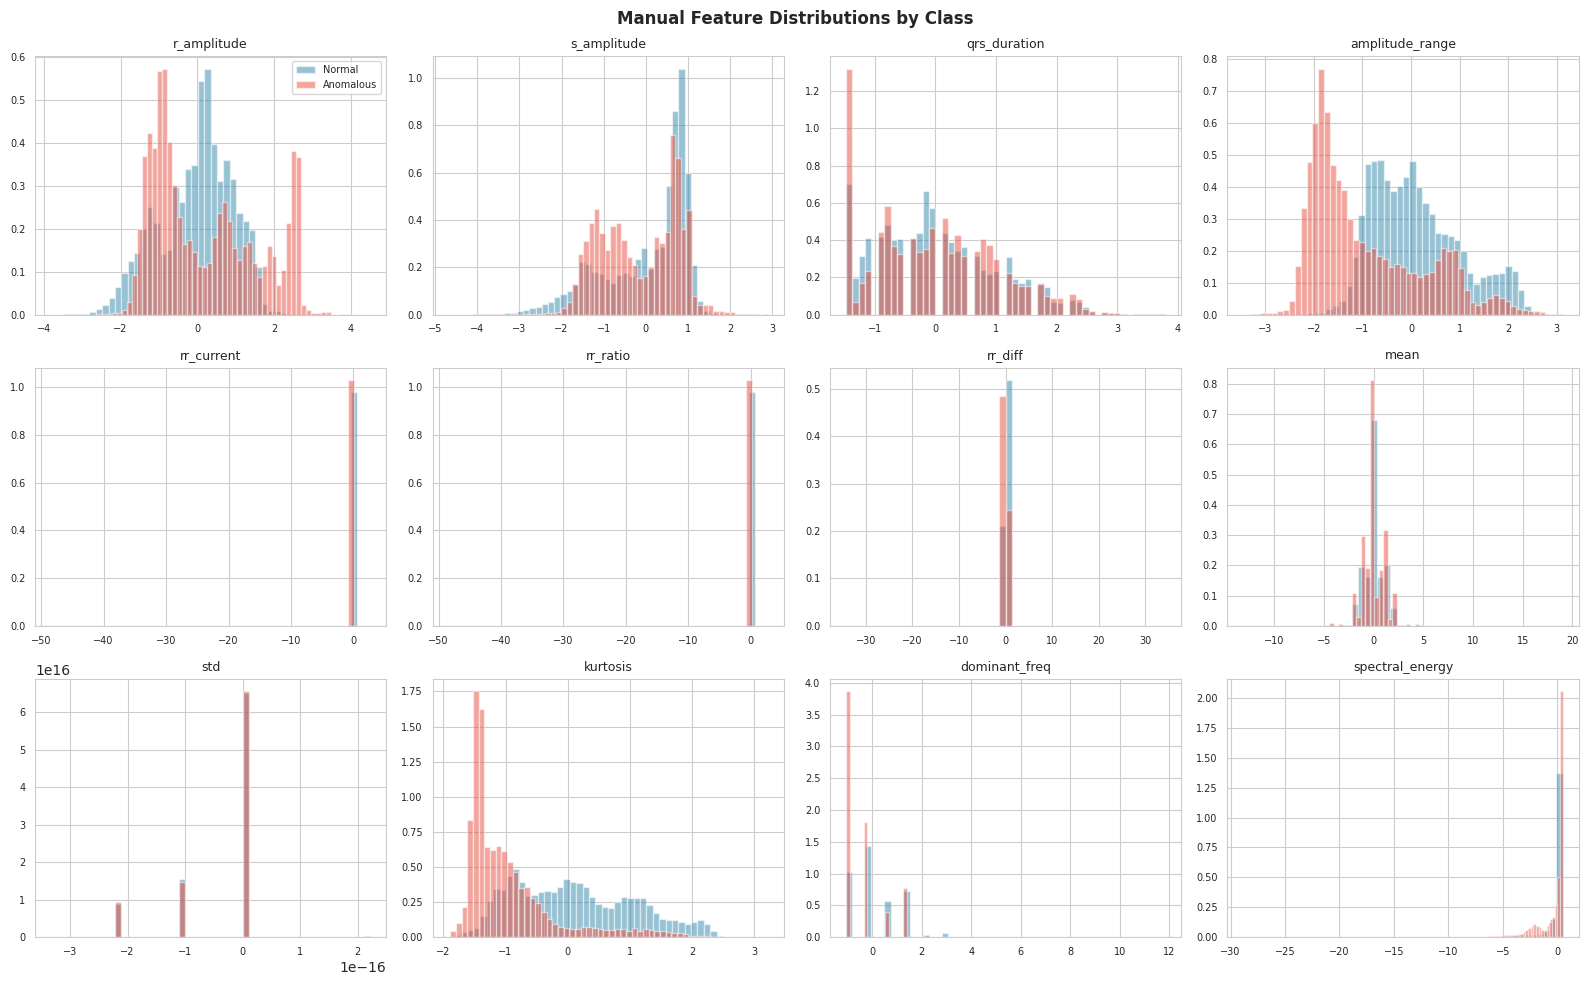

In [8]:
# Feature distributions: Normal vs Anomalous
df = pd.DataFrame(X_manual, columns=FEATURE_NAMES)
df["label"] = preprocessed.labels
df["class"] = df["label"].map({0: "Normal", 1: "Anomalous"})

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, feat in zip(axes.flat, FEATURE_NAMES):
    for label, color, name in [(0, "#2E86AB", "Normal"), (1, "#E74C3C", "Anomalous")]:
        vals = df[df["label"] == label][feat]
        ax.hist(vals, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7)
plt.suptitle("Manual Feature Distributions by Class", fontweight="bold")
plt.tight_layout()
plt.show()

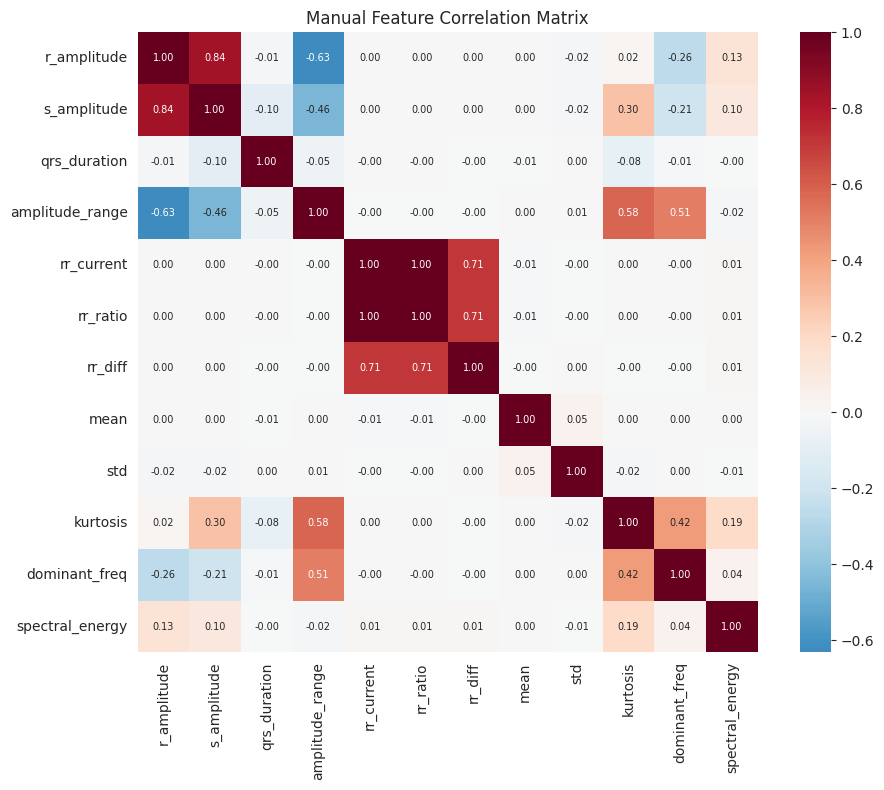

In [9]:
# Correlation matrix of manual features
fig, ax = plt.subplots(figsize=(10, 8))
corr = pd.DataFrame(X_manual, columns=FEATURE_NAMES).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, annot_kws={"fontsize": 7})
ax.set_title("Manual Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Comparison: PCA vs Manual Features

Side-by-side 2D scatter of both representations.

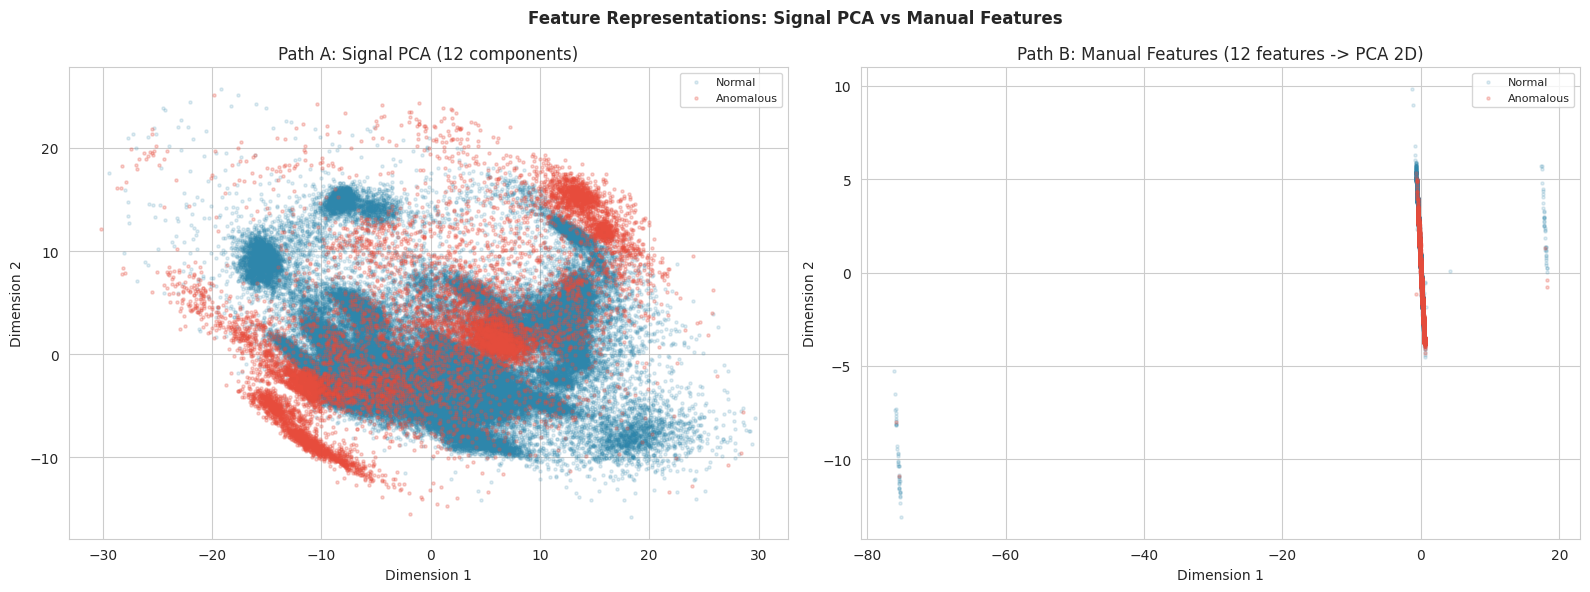

In [10]:
# Apply PCA to manual features for 2D visualization
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_manual_2d = pca_2d.fit_transform(X_manual)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, title in [
    (axes[0], X_pca[:, :2], f"Path A: Signal PCA ({pca_extractor.n_components} components)"),
    (axes[1], X_manual_2d, f"Path B: Manual Features ({len(FEATURE_NAMES)} features -> PCA 2D)"),
]:
    ax.scatter(X_2d[normal_mask, 0], X_2d[normal_mask, 1], alpha=0.15, s=5, c="#2E86AB", label="Normal")
    ax.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], alpha=0.25, s=5, c="#E74C3C", label="Anomalous")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Feature Representations: Signal PCA vs Manual Features", fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# Autoencoder input: scaled signal without PCA
X_autoencoder = pca_extractor.get_raw_for_autoencoder(preprocessed.segments)
print(f"Autoencoder input shape: {X_autoencoder.shape} (full scaled signal, no PCA)")
print(f"Clustering input shape (PCA): {X_pca.shape}")
print(f"Clustering input shape (Manual): {X_manual.shape}")

Autoencoder input shape: (100705, 200) (full scaled signal, no PCA)
Clustering input shape (PCA): (100705, 12)
Clustering input shape (Manual): (100705, 12)


## Summary

| Representation | Dimensions | Description |
|---|---|---|
| Signal PCA | ~k (95% var) | Direct waveform reduced via PCA |
| Manual Features | 12 | Handcrafted morphological/temporal/spectral |
| Autoencoder Input | 200 | Full scaled signal (AE learns its own compression) |

Both representations show some separation between normal and anomalous beats
in the 2D projections, though there is significant overlap -- consistent
with the challenge of unsupervised anomaly detection.

**Next:** `04_clustering.ipynb` -- apply the 4 unsupervised models.